# Vision Transformer (ViT) from Scratch — Plant Disease Classification
**Dataset:** New Plant Diseases Dataset (Augmented) — 38 classes  
**Paper:** *An Image is Worth 16x16 Words* (Dosovitskiy et al., 2020)

## 1. Imports

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
CONFIG = {
    'ROOT_DIR': r'D:\Leaf dataset 2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)',
    'OUTPUT_DIR': r'D:\Leaf dataset 2\outputs\ViT',
    'IMG_SIZE': 224,
    'BATCH_SIZE': 16,        # ↓ reduced from 32 to save GPU memory
    'EPOCHS': 30,
    'NUM_CLASSES': 38,
    'LEARNING_RATE': 1e-4,
    'SEED': 42,
    # ── ViT-Mini config (lighter than Tiny — fits most GPUs) ──────────
    'PATCH_SIZE': 16,        # 224/16 = 14 -> 196 patches
    'EMBED_DIM': 128,        # ↓ reduced from 192
    'NUM_HEADS': 4,          # must divide EMBED_DIM evenly
    'MLP_DIM': 512,          # ↓ reduced from 768
    'NUM_LAYERS': 8,         # ↓ reduced from 12
    'DROPOUT_RATE': 0.1,
}

# Mixed precision: uses float16 for compute, float32 for weights
# Cuts GPU memory usage roughly in half with no accuracy loss
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)

tf.random.set_seed(CONFIG['SEED'])
np.random.seed(CONFIG['SEED'])

TRAIN_DIR = os.path.join(CONFIG['ROOT_DIR'], 'train')
VALID_DIR = os.path.join(CONFIG['ROOT_DIR'], 'valid')
OUT_DIR   = CONFIG['OUTPUT_DIR']
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE    = CONFIG['IMG_SIZE']
BATCH_SIZE  = CONFIG['BATCH_SIZE']
EPOCHS      = CONFIG['EPOCHS']
NUM_CLASSES = CONFIG['NUM_CLASSES']
LR          = CONFIG['LEARNING_RATE']

print('Config loaded ✅')


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9
Mixed precision policy: mixed_float16
Config loaded ✅


## 3. Data Loading
> No `test` folder in dataset — `valid` set is used for both training validation and final evaluation.

In [3]:
def build_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True,
        seed=CONFIG['SEED'],
    )
    valid_ds = tf.keras.utils.image_dataset_from_directory(
        VALID_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False,
    )

    class_names = train_ds.class_names
    print(f'\n✅  Found {len(class_names)} classes.')
    print('ℹ️  Using valid set for final evaluation (no test folder).')

    augmentation = tf.keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.15),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    normalize = layers.Rescaling(1.0 / 255)

    def preprocess_train(x, y):
        x = augmentation(x, training=True)
        x = normalize(x)
        return x, y

    def preprocess_eval(x, y):
        x = normalize(x)
        return x, y

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    valid_ds = valid_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, valid_ds, class_names


train_ds, valid_ds, class_names = build_datasets()
print('Class names:', class_names[:5], '...')

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.

✅  Found 38 classes.
ℹ️  Using valid set for final evaluation (no test folder).
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] ...


## 4. ViT Building Blocks

In [4]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim
        self.projection = layers.Conv2D(
            filters=embed_dim, kernel_size=patch_size,
            strides=patch_size, padding='valid',
        )
        self.flatten = layers.Reshape((-1, embed_dim))

    def call(self, images):
        x = self.projection(images)
        return self.flatten(x)

    def get_config(self):
        config = super().get_config()
        config.update({'patch_size': self.patch_size, 'embed_dim': self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), initializer='zeros',
            trainable=True, name='cls_token'
        )
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer='random_normal', trainable=True, name='pos_embed'
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, (batch_size, 1, self.embed_dim))
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'embed_dim': self.embed_dim})
        return config


class ExtractCLS(layers.Layer):
    """Extracts the CLS token (index 0) from the sequence. Serializable — no Lambda needed."""
    def call(self, x):
        return x[:, 0, :]

    def get_config(self):
        return super().get_config()


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.mlp_dim      = mlp_dim
        self.dropout_rate = dropout_rate
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout_rate
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.fc1   = layers.Dense(mlp_dim, activation='gelu')
        self.fc2   = layers.Dense(embed_dim)
        self.drop  = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.attn(self.norm1(x), self.norm1(x), training=training)
        x = x + self.drop(attn_out, training=training)
        mlp_out = self.fc2(self.drop(self.fc1(self.norm2(x)), training=training))
        return x + self.drop(mlp_out, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'mlp_dim':   self.mlp_dim,
            'dropout_rate': self.dropout_rate,
        })
        return config


print('ViT building blocks defined ✅')


ViT building blocks defined ✅


## 5. Build ViT Model

In [5]:
def build_vit(num_classes):
    patch_size   = CONFIG['PATCH_SIZE']
    embed_dim    = CONFIG['EMBED_DIM']
    num_heads    = CONFIG['NUM_HEADS']
    mlp_dim      = CONFIG['MLP_DIM']
    num_layers   = CONFIG['NUM_LAYERS']
    dropout_rate = CONFIG['DROPOUT_RATE']
    num_patches  = (IMG_SIZE // patch_size) ** 2

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim)(inputs)
    x = PositionalEmbedding(num_patches=num_patches, embed_dim=embed_dim)(x)
    x = layers.Dropout(dropout_rate)(x)

    for i in range(num_layers):
        x = TransformerBlock(
            embed_dim=embed_dim, num_heads=num_heads,
            mlp_dim=mlp_dim, dropout_rate=dropout_rate,
            name=f'transformer_block_{i}',
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = ExtractCLS()(x)                                      # serializable CLS extraction
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(num_classes, dtype='float32')(x)        # float32 for stable softmax
    outputs = layers.Activation('softmax', dtype='float32')(x)

    return Model(inputs, outputs, name='ViT_scratch')


model = build_vit(num_classes=NUM_CLASSES)
model.summary()


Model: "ViT_scratch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 patch_embedding (PatchEmbed  (None, 196, 128)         98432     
 ding)                                                           
                                                                 
 positional_embedding (Posit  (None, 197, 128)         25344     
 ionalEmbedding)                                                 
                                                                 
 dropout (Dropout)           (None, 197, 128)          0         
                                                                 
 transformer_block_0 (Transf  (None, 197, 128)         198272    
 ormerBlock)                                                     
                                                       

## 6. Compile

In [6]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
print('Model compiled ✅')

Model compiled ✅


## 7. Callbacks

In [7]:
cb_list = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(OUT_DIR, 'ViT_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.CSVLogger(os.path.join(OUT_DIR, 'ViT_log.csv')),
]
print('Callbacks ready ✅')

Callbacks ready ✅


## 8. Train

In [8]:
t0 = time.time()

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

elapsed_min = (time.time() - t0) / 60
print(f'\nTraining completed in {elapsed_min:.1f} minutes')

Epoch 1/30
4394/4394 [==============================] - ETA: 0s - loss: 2.0060 - accuracy: 0.4248
Epoch 1: val_accuracy improved from -inf to 0.74619, saving model to D:\Leaf dataset 2\outputs\ViT\ViT_best.keras
4394/4394 [==============================] - 792s 171ms/step - loss: 2.0060 - accuracy: 0.4248 - val_loss: 0.8088 - val_accuracy: 0.7462 - lr: 1.0000e-04
Epoch 2/30
4394/4394 [==============================] - ETA: 0s - loss: 0.7892 - accuracy: 0.7502
Epoch 2: val_accuracy improved from 0.74619 to 0.85471, saving model to D:\Leaf dataset 2\outputs\ViT\ViT_best.keras
4394/4394 [==============================] - 720s 163ms/step - loss: 0.7892 - accuracy: 0.7502 - val_loss: 0.4612 - val_accuracy: 0.8547 - lr: 1.0000e-04
Epoch 3/30
4394/4394 [==============================] - ETA: 0s - loss: 0.5380 - accuracy: 0.8284
Epoch 3: val_accuracy improved from 0.85471 to 0.88954, saving model to D:\Leaf dataset 2\outputs\ViT\ViT_best.keras
4394/4394 [==============================] - 732s 

## 9. Training Curves

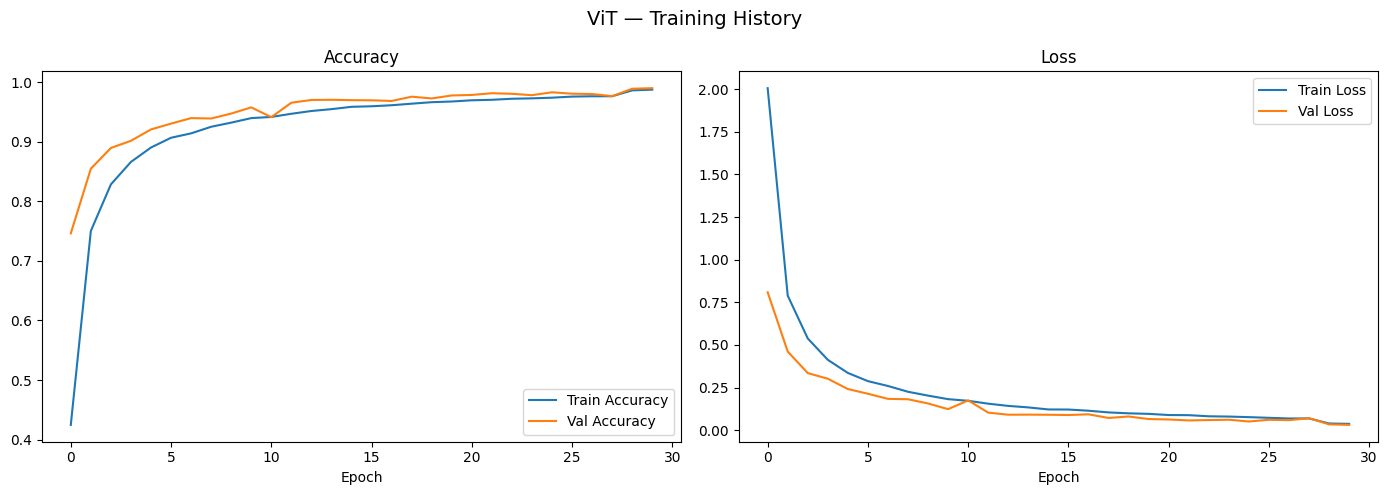

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT — Training History', fontsize=14)

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ViT_history.png'), dpi=150)
plt.show()

## 10. Evaluation (Validation Set)

In [10]:
print('Evaluating on validation set …')
y_true, y_pred = [], []

for x_batch, y_batch in valid_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open(os.path.join(OUT_DIR, 'ViT_classification_report.txt'), 'w') as f:
    f.write(report)

eval_accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f'Evaluation Accuracy: {eval_accuracy:.4f}')

Evaluating on validation set …
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9960    0.9980       504
                                 Apple___Black_rot     0.9920    0.9980    0.9950       497
                          Apple___Cedar_apple_rust     0.9820    0.9932    0.9876       440
                                   Apple___healthy     0.9901    0.9960    0.9930       502
                               Blueberry___healthy     0.9868    0.9846    0.9857       454
          Cherry_(including_sour)___Powdery_mildew     0.9976    1.0000    0.9988       421
                 Cherry_(including_sour)___healthy     0.9978    1.0000    0.9989       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     1.0000    0.9561    0.9776       410
                       Corn_(maize)___Common_rust_     0.9917    1.0000    0.9958       477
               Corn_(maize)___Northern_Leaf_Blig

## 11. Confusion Matrix

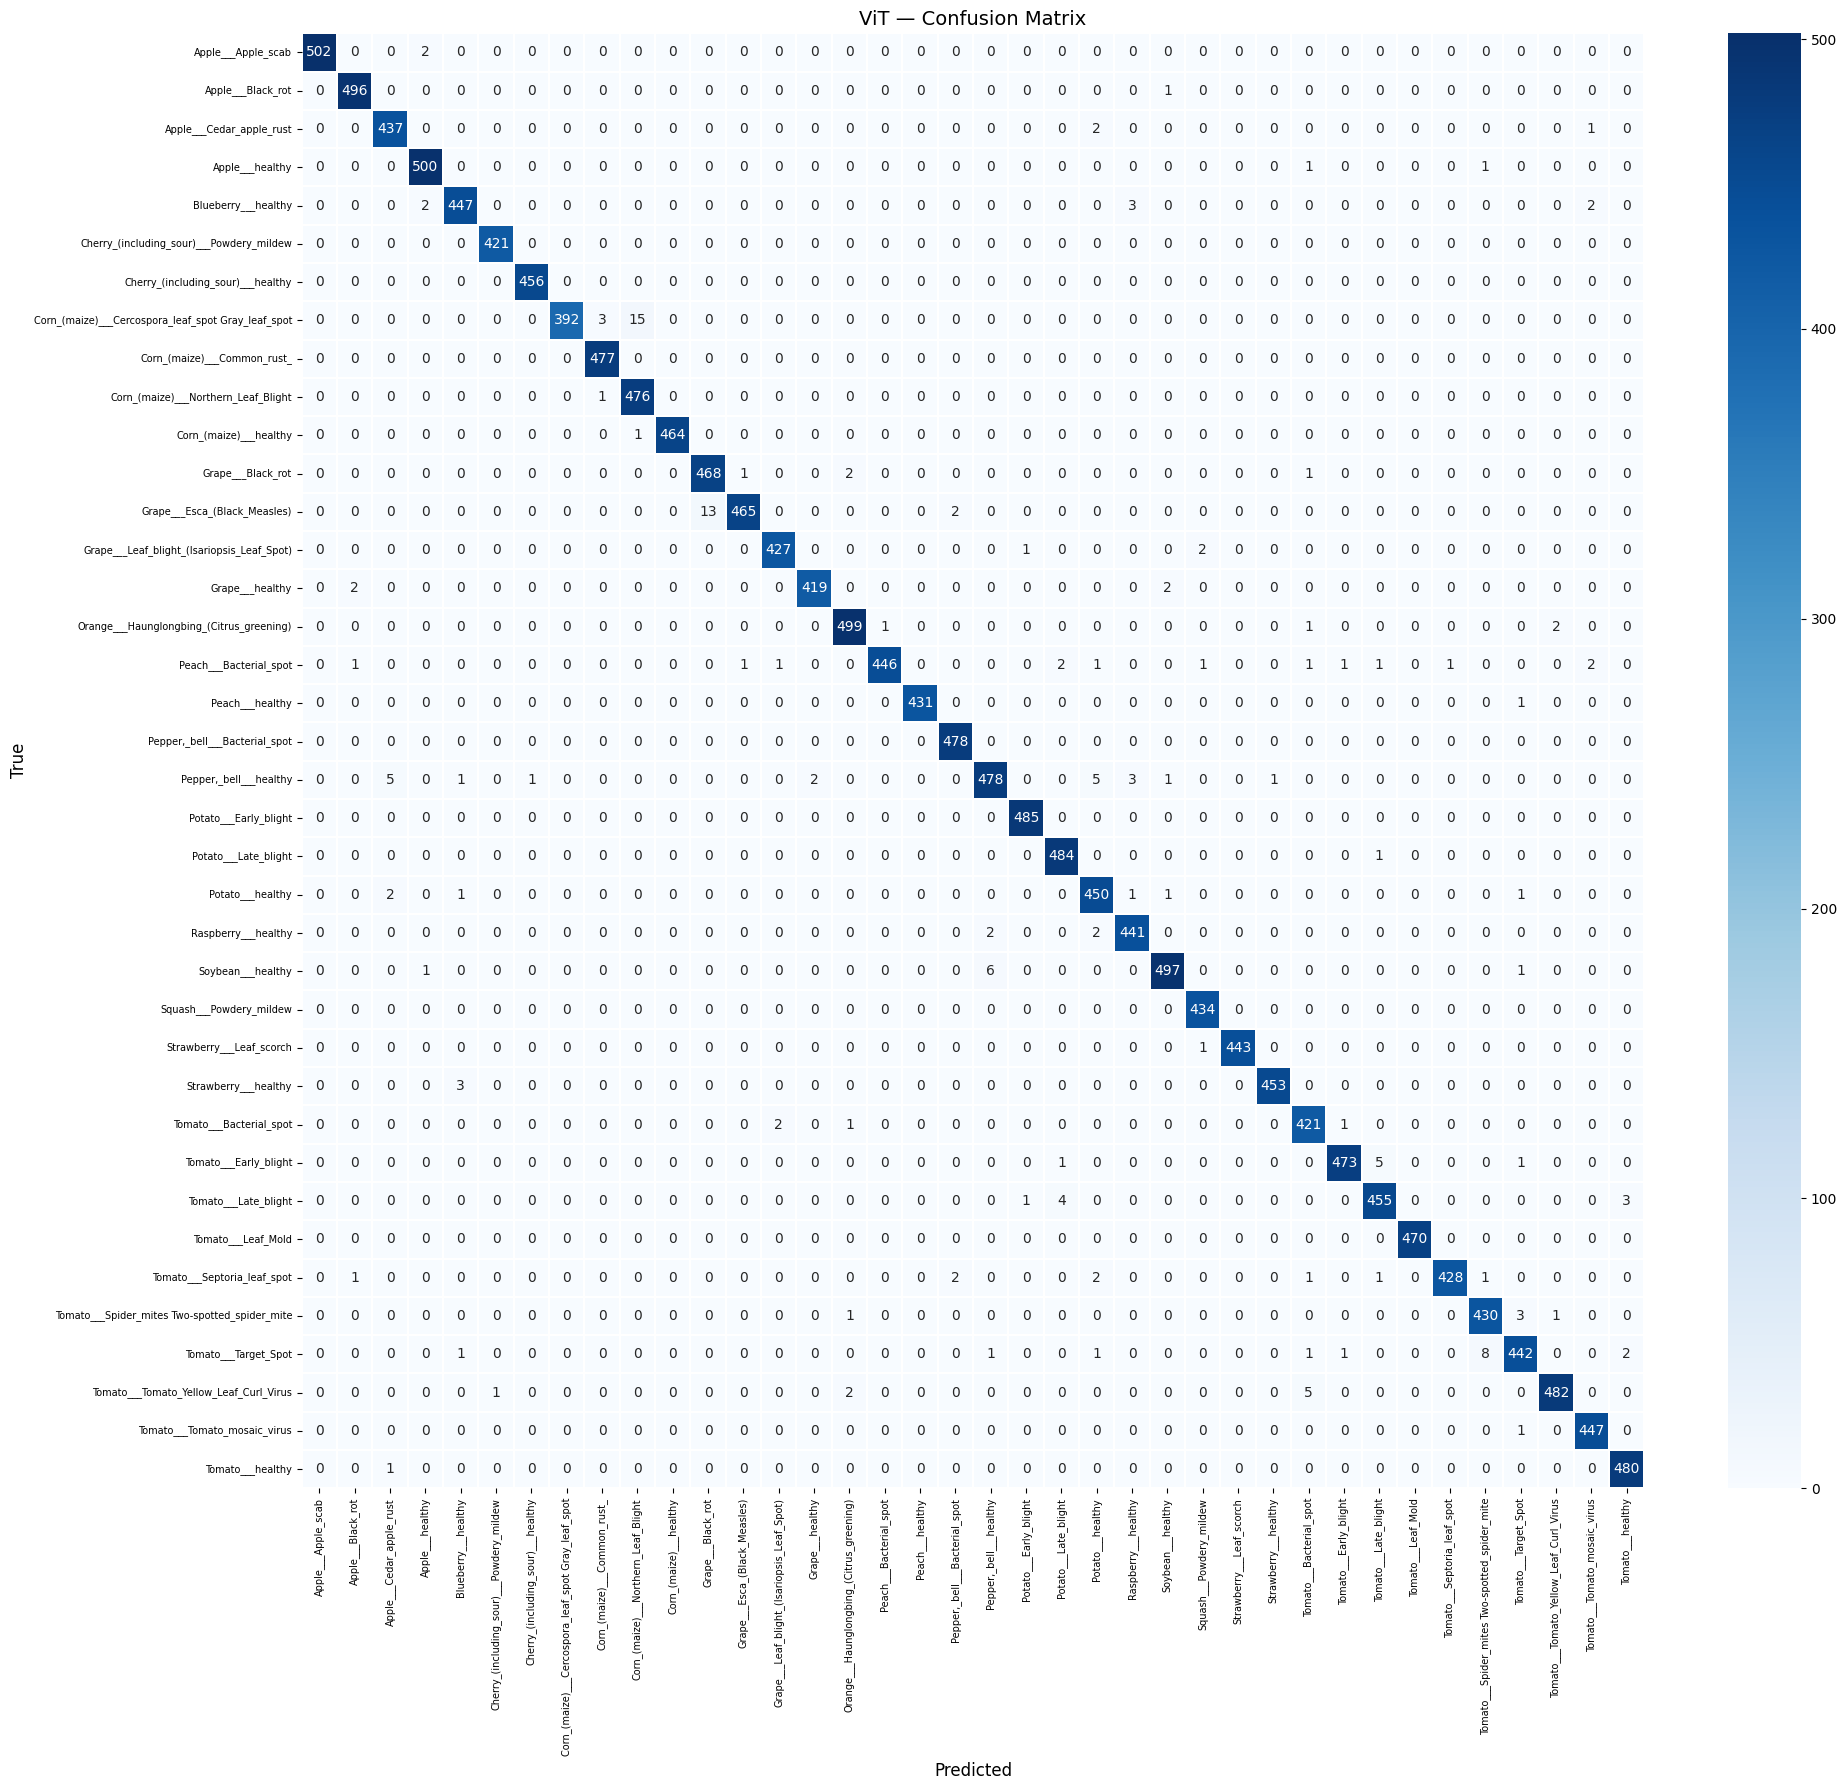

In [11]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, linewidths=0.3,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('ViT — Confusion Matrix', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ViT_confusion_matrix.png'), dpi=150)
plt.show()

## 12. Save Model & Results

In [12]:
model.save(os.path.join(OUT_DIR, 'ViT_final.keras'))

result = {
    'best_val_accuracy': round(max(history.history['val_accuracy']), 4),
    'eval_accuracy':     round(eval_accuracy, 4),
    'train_time_min':    round(elapsed_min, 2),
    'epochs_run':        len(history.history['loss']),
}
with open(os.path.join(OUT_DIR, 'result.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('\n📋 Final Results:')
for k, v in result.items():
    print(f'  {k}: {v}')
print(f'\n💾 All outputs saved to: {OUT_DIR}')


📋 Final Results:
  best_val_accuracy: 0.9899
  eval_accuracy: 0.9899
  train_time_min: 199.18
  epochs_run: 30

💾 All outputs saved to: D:\Leaf dataset 2\outputs\ViT
